# Lab08：從偵測到根因，一步一個試驗

## 這一節怎麼走

前面五節每一節教一類方法。這一節不介紹新方法，它示範一件事：拿到資料之後，**怎麼決定下一步要試什麼**。

規則只有一條，而且從頭到尾不變。

> 每一步跑一個試驗，量一個數字，讀出這個數字暴露的缺陷，缺陷指定下一步。

所以每一步都會出現三樣東西：一次執行、一個量到的值、一句「所以下一步要試什麼」。試到後來會遇到
兩種結局，一種是缺陷修好了，另一種是量到的進步已經小於雜訊。第二種比第一種重要，因為它是停手的
訊號，而多數人不知道什麼時候該停。

## 三個部分，重量不一樣

**目標是偵測。** 第 1 到第 9 步。這部分會比想像中早結束，因為它比想像中簡單。

**基礎是進階異常指標。** 第 10 到第 13 步。偵測停手之後才看得出來，這些指標真正的價值不在偵測。

**承重的是根因分析。** 第 14 到第 22 步，全課最長的一段。偵測告訴你有事，根因才告訴你要做什麼。

**最後交給 LLM 解讀。** 第 23 到第 27 步。你會親手把 prompt 貼進聊天視窗，把回覆貼回來，讓
notebook 執行模型要求的工具，再把結果貼回去。這是 agentic pipeline 真正的樣子，只是傳話的人
是你。

## 你需要準備的

一個可以開的 LLM 聊天視窗，任何一個都行。前 22 步不需要它。

In [1]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lib.lib import set_figure_style, C, PORT_C, heatmap
from lib.features import (load_telemetry, load_catalog, load_calendar, engineer_features,
                          calendar_mask, counterfactual_normal, attenuate_events,
                          season_key, SEASON_KEYS, FEATURES, RAW_COLUMNS,
                          FAULT_SIGNATURE, CADENCE_S)
from lib.detect import fit_fleet, score_fleet, baseline_scores, DETECTORS
from lib import evaluate as ev
from lib import rca

set_figure_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

ladder = ev.Ladder()          # 每一步的結果都記在這裡，最後一步會把整條路畫出來

telemetry, contract = load_telemetry()
catalog = load_catalog()
calendar = load_calendar()
print(contract.describe())

rows            43,200 across 5 ports
span            2026-02-01 00:00:00  ->  2026-03-02 23:55:00
cadence         300 s (5 min, 288 samples/day)
column reading  per-interval totals, already differenced
monotonic frac  0.503 of consecutive INOCTETS steps are non-negative
missing cells   0
duplicate rows  0
note            rates come from dividing by the cadence, not from a diff
note            INNUCASTPKTS is smaller than broadcast+multicast on some rows
note            286 rows carry an incident label (0.662% prevalence)


---
# 第一部　目標：偵測

## 第 1 步　試驗：這些欄位可以當累計值讀嗎

SNMP 的 octet counter 只會往上加，所以要算速率必須先做差分。差分之前要先確認它真的是 counter，
而確認的方法是量相鄰兩筆的差有多少是非負的。真的 counter 會是九成九以上。

**量到 0.503。** 一半往上一半往下，這不是 counter，是每個區間已經算好的量。再差分一次會得到雜訊，
而且不會有任何錯誤訊息。

**下一步：** 既然欄位是區間量，速率就是除以 cadence。先做特徵，然後做第一個偵測器。

In [2]:
frame = engineer_features(telemetry)
is_event = frame["event_label"].ne("normal").to_numpy()
planned = calendar_mask(frame, calendar)

header, counters, quality = ev.data_quality_report(frame, RAW_COLUMNS, FEATURES)
print(header)
display(counters.head(4))
ladder.record(1, "read INOCTETS as a counter", "monotonic_fraction",
              round(contract.monotonic_fraction, 3),
              "0.503 is not a counter, it is a per-interval total",
              "divide by cadence instead of differencing")

{'rows': 43200, 'ports': 5, 'missing_cells': 0, 'duplicate_port_time': 0}


,counter,negative_step_frac,zero_frac
0,INOCTETS,0.497,0.000
1,OUTOCTETS,0.498,0.000
2,INERRORS,0.015,0.985
3,OUTERRORS,0.010,0.990


{'step': 1,
 'trial': 'read INOCTETS as a counter',
 'metric': 'monotonic_fraction',
 'value': 0.503,
 'verdict': '0.503 is not a counter, it is a per-interval total',
 'next_step': 'divide by cadence instead of differencing'}

## 第 2 步　試驗：最笨的偵測器，一條固定門檻

先做最簡單的，看一個欄位 `in_bps`，超過一條線就告警。門檻用 false-onset budget 訂，一個 port
一天 0.5 次，跟 Lab04 同一個數字，這樣後面每一步都在同一個預算下比較。

**量到 recall 0.278。** 十八個事件視窗只抓到五個。

**為什麼：** `in_bps` 只在流量變大時會動。broadcast storm 改變的是組成，link quality 問題改變的
是錯誤率，這些事件的 `in_bps` 幾乎不動。

**下一步：** 看十一個欄位，不要只看一個。

In [3]:
FIT_END, CAL_END = pd.Timestamp("2026-02-15"), pd.Timestamp("2026-02-19")
BUDGET = 0.5                                # false onsets per port per day

fit_mask = (frame["timestamp"] < FIT_END).to_numpy() & ~is_event & ~planned
cal_mask = ((frame["timestamp"] >= FIT_END)
            & (frame["timestamp"] < CAL_END)).to_numpy() & ~is_event & ~planned
windows = ev.event_windows(frame)

def try_detector(score, label):
    # 一個 score 進來，訂門檻、告警、算成績。整本 notebook 的比較都走這個函式。
    s = pd.DataFrame({label: pd.Series(score, index=frame.index)})
    th = ev.calibrate_fleet(frame, s, cal_mask, BUDGET, cadence_s=CADENCE_S)
    card = ev.event_scorecard(frame, ev.flag_fleet(frame, s, th), windows,
                              cadence_s=CADENCE_S).iloc[0]
    return card, th

card, _ = try_detector(baseline_scores(frame, "in_bps", fit_mask, "raw"), "fixed limit")
print(f"fixed limit on in_bps       recall {card.event_recall:.3f}   "
      f"false/port/day {card.false_onsets_per_port_day:.2f}")
ladder.record(2, "fixed limit, in_bps only", "event_recall", card.event_recall,
              "misses every event that does not change volume",
              "watch all 11 features, not one")

fixed limit on in_bps       recall 0.278   false/port/day 0.69


{'step': 2,
 'trial': 'fixed limit, in_bps only',
 'metric': 'event_recall',
 'value': np.float64(0.278),
 'verdict': 'misses every event that does not change volume',
 'next_step': 'watch all 11 features, not one'}

## 第 3 步　試驗：十一個欄位一起看

每個欄位各自標準化，取最大的那個偏離量當分數。Lab04 把這個叫 marginal baseline。

**量到 recall 1.000。** 十八個視窗全中。

**看起來解決了，而這正是要小心的地方。** 一個滿分的結果沒有辦法告訴你下一步該做什麼，也沒有辦法
告訴你這個方法好在哪裡。接下來三步會用不同的 baseline 再試，如果每一個都是 1.000，那代表題目本身
太簡單，量到的不是方法的好壞。

**下一步：** 換掉 global 的平均值，改用時段 baseline，看看有沒有差別。

In [4]:
trials = {}
for kind, label in (("global_z", "3 global z"),
                    ("hour", "4 hour-of-day"),
                    ("weekend_hour", "5 weekday/weekend x hour"),
                    ("week", "6 hour-of-week")):
    score = baseline_scores(frame, FEATURES, fit_mask, kind)
    s = pd.DataFrame({label: score})
    th = ev.calibrate_fleet(frame, s, cal_mask, BUDGET, cadence_s=CADENCE_S)
    card = ev.event_scorecard(frame, ev.flag_fleet(frame, s, th), windows,
                              cadence_s=CADENCE_S).iloc[0]
    trials[label] = (kind, score, th, card)
    print(f"{label:28s} buckets {SEASON_KEYS.get(kind, 1):3d}   "
          f"recall {card.event_recall:.3f}   "
          f"false/port/day {card.false_onsets_per_port_day:.2f}")

ladder.record(3, "global z, 11 features", "event_recall",
              trials["3 global z"][3].event_recall,
              "recall is perfect, so recall can no longer rank anything",
              "watch the false-alert rate instead")

3 global z                   buckets   1   recall 1.000   false/port/day 0.76


4 hour-of-day                buckets  24   recall 1.000   false/port/day 0.46


5 weekday/weekend x hour     buckets  48   recall 1.000   false/port/day 0.52


6 hour-of-week               buckets 168   recall 1.000   false/port/day 0.73


{'step': 3,
 'trial': 'global z, 11 features',
 'metric': 'event_recall',
 'value': np.float64(1.0),
 'verdict': 'recall is perfect, so recall can no longer rank anything',
 'next_step': 'watch the false-alert rate instead'}

## 第 4 到第 6 步　試驗：時段 baseline 的粗細

這座 fleet 平日的中位流量大約是週末的 1.7 倍，所以直覺上時段切得越細越好。三個切法一起量：
一天 24 格、平日與週末各 24 格共 48 格、一週 168 格。

**recall 全部是 1.000，沒有任何差別。** 有差別的是誤報率，而方向和直覺相反：24 格最低 0.46，
168 格最高 0.73。切得最細的反而最吵。

**為什麼：** fit 期只有 13 天，不到兩週。切成 168 格之後，每一格只剩大約 24 個樣本可以估平均與
標準差，估計本身就在抖。格子越細，模型越貼近形狀，每一格的估計越不穩，這是 bias 與 variance 的
交換，不是可以兩邊都要的東西。

**下一步：** 這三個差異有多大？在下結論之前要先知道 0.46 和 0.73 的差距是不是真的。先把尺度換成
robust 的版本，再一起檢查。

In [5]:
one = frame[frame["port_id"] == "port-id7429"]
keep = fit_mask[one.index.to_numpy()]
print("samples available per bucket, on the fit period:")
for kind in ("hour", "weekend_hour", "week"):
    counts = pd.Series(season_key(one["timestamp"], kind)[keep]).value_counts()
    print(f"  {kind:14s} {SEASON_KEYS[kind]:3d} buckets   "
          f"median {int(counts.median()):3d} samples, min {int(counts.min()):3d}")

for step, (kind, label) in enumerate((("hour", "4 hour-of-day"),
                                      ("weekend_hour", "5 weekday/weekend x hour"),
                                      ("week", "6 hour-of-week")), start=4):
    card = trials[label][3]
    ladder.record(step, label.split(" ", 1)[1], "false_onsets_per_port_day",
                  card.false_onsets_per_port_day,
                  f"recall still 1.000; {SEASON_KEYS[kind]} buckets",
                  "check whether these gaps beat the noise")
display(ladder.show(since=3))

samples available per bucket, on the fit period:
  hour            24 buckets   median 168 samples, min 163
  weekend_hour    48 buckets   median  84 samples, min  43
  week           168 buckets   median  24 samples, min  19


,step,trial,metric,value,verdict
0,3,"global z, 11 features",event_recall,1.00,"recall is perfect, so recall can no longer ran..."
1,4,hour-of-day,false_onsets_per_port_day,0.46,recall still 1.000; 24 buckets
2,5,weekday/weekend x hour,false_onsets_per_port_day,0.52,recall still 1.000; 48 buckets
3,6,hour-of-week,false_onsets_per_port_day,0.73,recall still 1.000; 168 buckets


## 第 7 步　試驗：把尺換成 median 與 MAD

平均值與標準差會被極端值拉走。換成中位數與 MAD，理論上參考期就算混進幾筆髒資料也還站得住。

**量到三個欄位的 MAD 是 0。** `error_rate`、`discard_rate`、`unknown_proto_pps` 在正常流量下
九成以上的樣本是零，中位數是零，絕對離差的中位數也是零，於是分母消失。

**這不是可以丟掉的三個欄位。** 十種事件裡有四種靠它們，包括 queue congestion、兩種線路品質問題
與 unknown protocol scan。丟掉它們，那四種事件之後永遠歸因不出來。

**處理方式：** MAD 為零時退回標準差，並且把退回的名單印出來，讓它出現在輸出裡而不是埋在程式碼裡。

**下一步：** 到這裡每一個 baseline 的 recall 都是 1.000。要繼續比較，必須先知道這些數字的誤差有
多大。

In [6]:
display(ev.degenerate_features(frame, FEATURES, mask=~is_event))
score = baseline_scores(frame, FEATURES, fit_mask, "robust_hour")
s = pd.DataFrame({"7 robust hour-of-day": score})
th_robust = ev.calibrate_fleet(frame, s, cal_mask, BUDGET, cadence_s=CADENCE_S)
card = ev.event_scorecard(frame, ev.flag_fleet(frame, s, th_robust), windows,
                          cadence_s=CADENCE_S).iloc[0]
print(f"robust hour-of-day           recall {card.event_recall:.3f}   "
      f"false/port/day {card.false_onsets_per_port_day:.2f}")
ladder.record(7, "robust scale, median and MAD", "false_onsets_per_port_day",
              card.false_onsets_per_port_day,
              "3 of 11 features have MAD 0 and fall back to the standard deviation",
              "measure the uncertainty on all of these numbers")

,feature,reason,mad,zero_frac
0,error_rate,MAD is zero; zero on 98% of rows,0.0,0.976
1,discard_rate,MAD is zero; zero on 92% of rows,0.0,0.916
2,unknown_proto_pps,MAD is zero; zero on 99% of rows,0.0,0.990


robust hour-of-day           recall 1.000   false/port/day 0.44


{'step': 7,
 'trial': 'robust scale, median and MAD',
 'metric': 'false_onsets_per_port_day',
 'value': np.float64(0.44),
 'verdict': '3 of 11 features have MAD 0 and fall back to the standard deviation',
 'next_step': 'measure the uncertainty on all of these numbers'}

## 第 8 步　試驗：這些數字的誤差有多大

證據的單位是事件，不是樣本。整份資料只有十個事件、十八個 (事件, port) 視窗，所以 recall 的信賴
區間要對視窗重抽來算。

**量到的 recall 區間是 [1.000, 1.000]。** 這不代表這些方法一樣好，它代表這個測試分不出它們。
區間退化成一個點，是因為每一個方法都抓到全部十八個視窗，重抽再多次也還是十八個。

**誤報率這一邊有真正的區間。** 同一個 port 上做 block bootstrap，四個時段切法的區間有的重疊有的
不重疊，而且和整個 fleet 平均出來的排名不一致。用一個平均值排名，會把 port 之間的差異藏起來。

**順帶量到 alert 的相鄰程度是獨立假設的幾十倍。** 一個樣本越線之後，下一個樣本越線的機率遠高於
它自己的邊際機率。任何「每樣本機率乘上樣本數」的 alert 量估算都會錯這麼多倍。

**下一步：** 原始強度下每個方法都滿分，recall 這把尺已經沒有解析度。必須把題目變難。

In [7]:
rows = []
one_port = frame[frame["port_id"] == "port-id7429"].index
for label, (kind, score, th, card) in trials.items():
    s = pd.DataFrame({label: score})
    port_flags = ev.flag_fleet(frame, s, th)
    boot = ev.bootstrap_windows(ev.window_outcomes(frame, port_flags[label], windows))
    rate = ev.block_bootstrap_rate(port_flags.loc[one_port, label], block=288, n_boot=400,
                                   cadence_s=CADENCE_S)
    rows.append({"trial": label, "recall": boot["recall"], "recall_ci": str(boot["ci95"]),
                 "false_onsets_per_day (one port)": rate["onsets_per_day"],
                 "false_ci": str(rate["ci95"])})
display(pd.DataFrame(rows))

print("\nadjacent-breach ratio against an independence assumption, robust hour-of-day:")
flags_robust = ev.flag_fleet(frame, pd.DataFrame({"7 robust hour-of-day": score}), th_robust)
for pid, group in frame.groupby("port_id"):
    got = ev.breach_independence(flags_robust.loc[group.index, "7 robust hour-of-day"])
    print(f"  {pid[-4:]}  observed {got['observed_adjacent']:3d}   "
          f"expected if independent {got['expected_if_independent']:5.1f}   "
          f"ratio {got['ratio']}")
ladder.record(8, "bootstrap the scorecard", "recall_ci_width", 0.0,
              "recall interval collapses to a point: the test is saturated",
              "make the task harder so recall can discriminate again")

,trial,recall,recall_ci,false_onsets_per_day (one port),false_ci
0,3 global z,1.0,"[1.0, 1.0]",1.13,"[0.67, 1.47]"
1,4 hour-of-day,1.0,"[1.0, 1.0]",1.23,"[0.93, 1.67]"
2,5 weekday/weekend x hour,1.0,"[1.0, 1.0]",0.10,"[0.03, 0.2]"
3,6 hour-of-week,1.0,"[1.0, 1.0]",0.10,"[0.03, 0.2]"



adjacent-breach ratio against an independence assumption, robust hour-of-day:
  7427  observed 8639   expected if independent 8639.0   ratio 1.0
  7428  observed 8635   expected if independent 8635.0   ratio 1.0
  7429  observed  43   expected if independent   4.0   ratio 10.9
  7430  observed 8639   expected if independent 8639.0   ratio 1.0
  7431  observed 8639   expected if independent 8639.0   ratio 1.0


{'step': 8,
 'trial': 'bootstrap the scorecard',
 'metric': 'recall_ci_width',
 'value': 0.0,
 'verdict': 'recall interval collapses to a point: the test is saturated',
 'next_step': 'make the task harder so recall can discriminate again'}

## 第 9 步　停手的訊號

第 3 步到第 7 步，recall 一直是 1.000，誤報率在 0.44 到 0.76 之間游走，而第 8 步量到的
recall 區間退化成一個點。**這把尺已經用完了。**

繼續調時段格數、調 robust 與否，是在調雜訊。這一步不是失敗，它是這一部分的結論：

- 這批資料上，偵測在第 3 步就做完了，用的是最簡單的方法。
- 之後每一步花的力氣，換到的都在誤差以內。
- 真正的問題不在「有沒有事」，而在「是什麼事」，那是第三部。

**下一步：** 在放下偵測之前，還有兩件事值得量。第一，把題目變難之後方法會不會分出高下。第二，
複雜的模型如果不能提升偵測，那它們的價值在哪裡。

---
# 第二部　基礎：進階異常指標

## 第 10 步　試驗：把事件調弱

真實世界的事件不會都像資料裡這麼明顯。`attenuate_events()` 把每一個事件視窗往它自己的
counterfactual 拉近，counterfactual 是同一個 port、同一個時段、正常樣本的中位數，也就是這段時間
如果什麼都沒發生大概會是多少。強度 1.0 是原始檔案，0.05 表示 counter 只走了原本的二十分之一。

混合加在 raw counter 上，特徵再從 counter 重算，所以封包數、位元組數與每一個比值之間的代數關係
都還成立。直接把特徵調弱會做出一個算術上不存在的 port。

模型與門檻在整個掃描中固定，唯一變動的是事件強度。

**量到的結果分成兩群。** 簡單的 marginal baseline 到 0.05 還是 1.000。多變量模型掉到 0.889。
IsolationForest 掉到 0.111。

**下一步：** 把每個 detector 撐得住的最低強度找出來，那是一個比 recall 更有資訊的數字。

In [8]:
counterfactual = counterfactual_normal(telemetry)
STRENGTHS = (1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01)

models = fit_fleet(frame, fit_mask, season="weekend_hour")
scores = score_fleet(frame, models)
thresholds = ev.calibrate_fleet(frame, scores, cal_mask, BUDGET, cadence_s=CADENCE_S)
flags = ev.flag_fleet(frame, scores, thresholds)

baseline_label = "marginal baseline"
baseline_score = baseline_scores(frame, FEATURES, fit_mask, "robust_hour")
th_base = ev.calibrate_fleet(frame, pd.DataFrame({baseline_label: baseline_score}),
                             cal_mask, BUDGET, cadence_s=CADENCE_S)

rows = []
for strength in STRENGTHS:
    weak = engineer_features(attenuate_events(telemetry, counterfactual, strength))
    got = ev.event_scorecard(weak, ev.flag_fleet(weak, score_fleet(weak, models), thresholds),
                             windows, cadence_s=CADENCE_S).set_index("detector")
    row = {d: got.loc[d, "event_recall"] for d in DETECTORS}
    wb = pd.DataFrame({baseline_label: baseline_scores(weak, FEATURES, fit_mask, "robust_hour")})
    row[baseline_label] = ev.event_scorecard(
        weak, ev.flag_fleet(weak, wb, th_base), windows, cadence_s=CADENCE_S).iloc[0].event_recall
    rows.append(pd.Series(row, name=strength))
recall_by_strength = pd.DataFrame(rows)
recall_by_strength.index.name = "strength"
display(recall_by_strength)

floors = pd.Series({c: min([i for i in recall_by_strength.index
                            if recall_by_strength.loc[i, c] >= 0.8], default=np.nan)
                    for c in recall_by_strength.columns}, name="detection floor")
display(floors.to_frame().T)

,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest,marginal baseline
strength,,,,,,,,
1.00,1.000,1.000,0.944,1.000,1.000,1.000,0.944,1.0
0.50,1.000,1.000,0.778,1.000,1.000,1.000,0.778,1.0
0.30,1.000,1.000,0.722,1.000,1.000,1.000,0.778,1.0
0.20,1.000,1.000,0.722,1.000,0.889,1.000,0.667,1.0
0.10,1.000,1.000,0.667,1.000,0.722,1.000,0.333,1.0
0.05,0.889,0.944,0.556,0.889,0.444,0.944,0.056,1.0
0.03,0.889,0.778,0.500,0.833,0.222,0.889,0.056,1.0
0.02,0.778,0.778,0.222,0.667,0.111,0.833,0.056,1.0
0.01,0.611,0.500,0.000,0.500,0.111,0.611,0.000,1.0


,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest,marginal baseline
detection floor,0.03,0.05,1.0,0.03,0.2,0.02,1.0,0.01


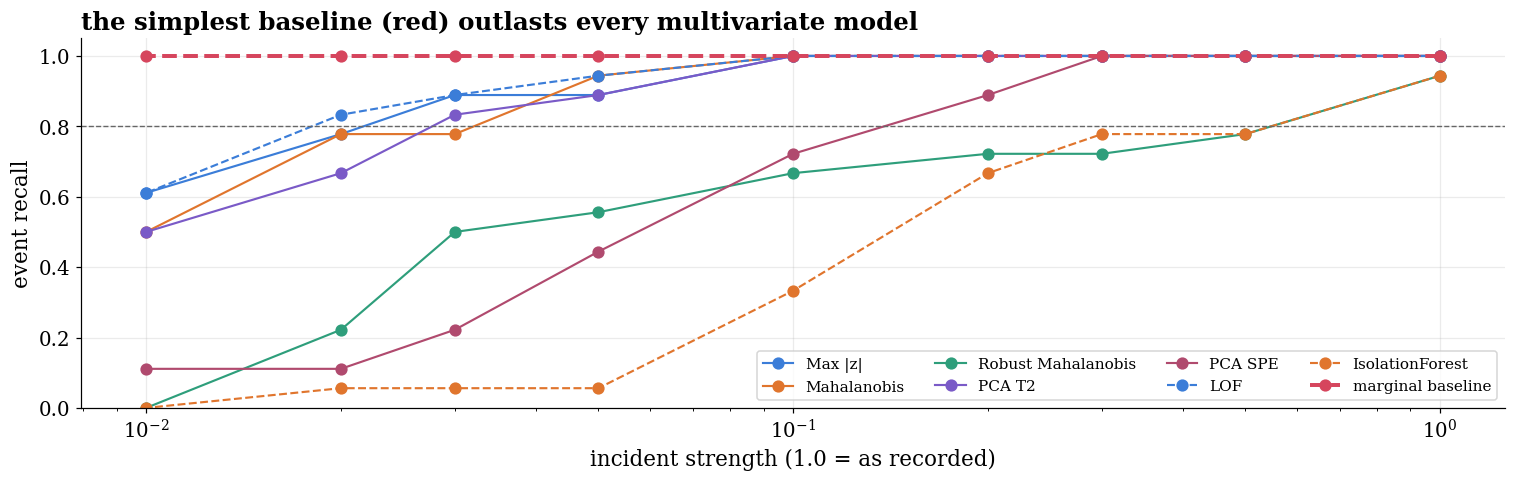

{'step': 10,
 'trial': 'attenuate incidents, sweep strength',
 'metric': 'detection_floor',
 'value': np.float64(0.01),
 'verdict': 'the marginal baseline holds to 0.01; IsolationForest breaks at 1.0',
 'next_step': 'ask what the multivariate models are for, if not recall'}

In [9]:
fig, ax = plt.subplots(figsize=(14, 4.6))
for k, det in enumerate(recall_by_strength.columns):
    ax.plot(recall_by_strength.index, recall_by_strength[det], marker="o",
            color=C["alert"] if det == baseline_label else PORT_C[k % len(PORT_C)],
            lw=2.6 if det == baseline_label else 1.4,
            ls=["-", "--", ":"][k // len(PORT_C)], label=det)
ax.axhline(0.8, color="0.4", ls="--", lw=0.9)
ax.set(xscale="log", xlabel="incident strength (1.0 = as recorded)", ylabel="event recall",
       ylim=(0, 1.05), title="the simplest baseline (red) outlasts every multivariate model")
ax.legend(fontsize=10, ncol=4, loc="lower right")
plt.show()

ladder.record(10, "attenuate incidents, sweep strength", "detection_floor",
              floors[baseline_label],
              "the marginal baseline holds to 0.01; IsolationForest breaks at 1.0",
              "ask what the multivariate models are for, if not recall")

## 第 11 步　那多變量模型到底買到了什麼

第 10 步的結果很不客氣：最簡單的 marginal baseline 在每一個強度上都不輸，IsolationForest 全程
墊底。如果只看偵測，這一節可以在第 3 步結束。

IsolationForest 掉得最快的原因值得看。它靠軸平行的切割把樣本隔離出來，在十一維裡它需要異常在
某個座標上明顯偏離；事件調弱之後每一維的偏移都變小，切割就切不出來。Max |z| 只看最極端的那一維，
所以衰減最慢。

先把第 8 步沒辦法做的事補上。題目變難之後 recall 不再滿分，信賴區間也就不再退化，下一格量到的
區間寬度大約是 ±0.15。多變量那幾個之間 0.889 與 0.944 的差距只有一個視窗，落在區間裡面，排名它們
沒有意義。marginal baseline 領先的那一段大於區間，那個差距是真的。

**偵測不是這些模型唯一能給的東西。** marginal baseline 的輸出是一個數字：最大偏離量是 42。
它沒辦法回答「這 42 裡面有多少是這個欄位造成的」，因為它本來就只看一個欄位。

多變量模型的輸出可以拆。PCA 的重建誤差可以逐欄拆開，Mahalanobis 可以把任一欄位換掉之後重算。
**第三部整個建立在這個能力上。** 這才是它們的用途。

**下一步：** 在進入根因之前，先量一個偵測上真的會用到的東西：參考期不乾淨的時候會怎樣。

In [10]:
weak = engineer_features(attenuate_events(telemetry, counterfactual, 0.05))
weak_scores = score_fleet(weak, models)
weak_flags = ev.flag_fleet(weak, weak_scores, thresholds)
rows = []
for det in DETECTORS:
    boot = ev.bootstrap_windows(ev.window_outcomes(weak, weak_flags[det], windows))
    rows.append({"detector": det, "recall": boot["recall"],
                 "ci95_low": boot["ci95"][0], "ci95_high": boot["ci95"][1]})
wb = pd.DataFrame({baseline_label: baseline_scores(weak, FEATURES, fit_mask, "robust_hour")})
boot = ev.bootstrap_windows(ev.window_outcomes(weak, ev.flag_fleet(weak, wb, th_base)[baseline_label],
                                               windows))
rows.append({"detector": baseline_label, "recall": boot["recall"],
             "ci95_low": boot["ci95"][0], "ci95_high": boot["ci95"][1]})
ci = pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)
display(ci)
maha = ci[ci["detector"] == "Mahalanobis"].iloc[0]
ladder.record(11, "bootstrap at strength 0.05", "ci_width",
              round(float(maha["ci95_high"] - maha["ci95_low"]), 3),
              "0.889 against 0.944 is one window, well inside the interval",
              "ask what the multivariate models buy, if not recall")

,detector,recall,ci95_low,ci95_high
0,marginal baseline,1.000,1.000,1.000
1,Mahalanobis,0.944,0.833,1.000
2,LOF,0.944,0.833,1.000
3,Max |z|,0.889,0.722,1.000
4,PCA T2,0.889,0.722,1.000
5,Robust Mahalanobis,0.556,0.333,0.778
6,PCA SPE,0.444,0.222,0.667
7,IsolationForest,0.056,0.000,0.167


{'step': 11,
 'trial': 'bootstrap at strength 0.05',
 'metric': 'ci_width',
 'value': 0.167,
 'verdict': '0.889 against 0.944 is one window, well inside the interval',
 'next_step': 'ask what the multivariate models buy, if not recall'}

## 第 12 步　試驗：參考期混進了事件

前面每一次 fit 都先把有標記的事件視窗拿掉，這是 Phase I 的標準作法。真實環境沒有這麼乾淨，因為
沒有人有一份完整的事件紀錄。這一步把事件留在參考期裡，其餘完全不動。

**要看的是 Mahalanobis 那一對。** 兩者的差別只有共變異數的估計法，其餘完全相同。強度 0.3 與 0.1
上，Robust Mahalanobis 掉了 0.000，一般 Mahalanobis 掉了 0.167 與 0.222。MinCovDet 只用一部分
樣本估共變異數，被污染的那幾筆落在支撐集外面，模型就沒有把事件學成正常。

**跨欄比平均值會誤導。** PCA SPE 的平均損失更小，理由是它在乾淨參考期下本來就很差，能掉的空間
有限。污染的代價只能在同一個家族內部比。

**保險的定價：** 參考期乾淨時 Robust Mahalanobis 在強度 1.0 只有 0.889，比一般 Mahalanobis 差
0.111，因為它主動丟掉一成資料。參考期可信就不要買，事件紀錄不完整就值得買。

**下一步：** 偵測部分到此為止。進入根因。

In [11]:
dirty_models = fit_fleet(frame, (frame["timestamp"] < FIT_END).to_numpy(), season="weekend_hour")
dirty_th = ev.calibrate_fleet(frame, score_fleet(frame, dirty_models), cal_mask, BUDGET,
                              cadence_s=CADENCE_S)
rows = []
for strength in (1.0, 0.3, 0.1, 0.05):
    weak = engineer_features(attenuate_events(telemetry, counterfactual, strength))
    clean = ev.event_scorecard(weak, ev.flag_fleet(weak, score_fleet(weak, models), thresholds),
                               windows, cadence_s=CADENCE_S).set_index("detector")
    dirty = ev.event_scorecard(weak, ev.flag_fleet(weak, score_fleet(weak, dirty_models),
                                                   dirty_th),
                               windows, cadence_s=CADENCE_S).set_index("detector")
    rows.append(pd.Series({d: round(dirty.loc[d, "event_recall"]
                                    - clean.loc[d, "event_recall"], 3)
                           for d in DETECTORS}, name=strength))
contamination = pd.DataFrame(rows)
contamination.index.name = "strength"
display(contamination[["Mahalanobis", "Robust Mahalanobis", "PCA T2", "PCA SPE",
                       "Max |z|", "LOF", "IsolationForest"]])
ladder.record(12, "contaminate the Phase I reference", "recall_lost_at_0.1",
              abs(contamination.loc[0.1, "Mahalanobis"]),
              "robust covariance loses 0.000 where the plain estimator loses 0.222",
              "move to root cause")

,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,Max |z|,LOF,IsolationForest
strength,,,,,,,
1.00,0.000,-0.111,0.000,-0.111,0.000,-0.111,0.000
0.30,-0.167,0.000,-0.222,-0.222,-0.056,0.000,-0.056
0.10,-0.222,0.000,-0.278,-0.166,-0.056,0.000,0.056
0.05,-0.222,-0.056,-0.278,0.000,-0.056,-0.055,0.055


{'step': 12,
 'trial': 'contaminate the Phase I reference',
 'metric': 'recall_lost_at_0.1',
 'value': np.float64(0.222),
 'verdict': 'robust covariance loses 0.000 where the plain estimator loses 0.222',
 'next_step': 'move to root cause'}

---
# 第三部　承重：根因分析

偵測回答「有沒有事」。工程師收到告警之後要回答的是另外四個問題，而前面五節沒有量過任何一個。

| 問題 | 量法 | 真值 |
| --- | --- | --- |
| 哪一個 counter 在動 | attribution hit@k | `FAULT_SIGNATURE`，由事件描述寫成 |
| 影響到哪些 port | localization | telemetry 的 `event_id` 與 `port_id` |
| 這是哪一種故障 | cause typing | `event_type` |
| 這是不是我們自己排的 | suppression | `change_calendar.csv` |

`FAULT_SIGNATURE` 從事件描述寫成，不是從資料擬合的。用同一份資料推出來的真值表去評分歸因，量到
的是自己的假設。表和資料不一致時，那是關於其中一方的發現，不是回頭改表的理由。

## 第 13 步　試驗：最直覺的歸因，哪一欄的偏離最大

In [12]:
DETECTOR = "Mahalanobis"
table = rca.attribution_table(models, frame, scores, windows, DETECTOR)
display(table[["event_id", "event_type", "port", "R0 max |z| top1", "R3 counterfactual top1"]])
summary = rca.attribution_summary(table)
chance = rca.random_baseline(k=1)
print(f"random top-1 pick would score {chance}")
display(summary)
ladder.record(13, "attribution: largest |z|", "hit@1",
              float(summary.loc[summary["attribution"] == "R0 max |z|", "hit@1"].iloc[0]),
              "0.889, and both failures share one mechanism",
              "look at what the two failures have in common")

,event_id,event_type,port,R0 max |z| top1,R3 counterfactual top1
0,A,business_traffic_growth,7430,multicast_ratio,in_pps
1,B,small_packet_scan,7428,out_pps,out_pps
2,C,large_file_backup,7431,multicast_ratio,multicast_ratio
3,D,queue_congestion,7427,discard_rate,discard_rate
4,E,link_quality_issue,7429,error_rate,error_rate
5,F,load_sensitive_link_issue,7427,error_rate,error_rate
6,G,broadcast_storm,7427,broadcast_ratio,broadcast_ratio
7,G,broadcast_storm,7428,broadcast_ratio,broadcast_ratio
8,G,broadcast_storm,7429,broadcast_ratio,broadcast_ratio
9,G,broadcast_storm,7430,broadcast_ratio,broadcast_ratio


random top-1 pick would score 0.209


,attribution,hit@1,hit@3
0,R3 counterfactual,0.944,1.000
1,R0 max |z|,0.889,1.000
2,R2 leave-one-out,0.778,0.889
3,R1 PCA SPE share,0.278,0.389


{'step': 13,
 'trial': 'attribution: largest |z|',
 'metric': 'hit@1',
 'value': 0.889,
 'verdict': '0.889, and both failures share one mechanism',
 'next_step': 'look at what the two failures have in common'}

In [13]:
wrong = table[~table["R0 max |z| hit@1"]]
print("every window R0 got wrong:")
display(wrong[["event_id", "event_type", "port", "R0 max |z| top1"]])

window = windows[windows["event_id"] == "A"].iloc[0]
mask = ((frame["port_id"] == window.port_id)
        & frame["timestamp"].between(window.start, window.end))
idx = frame.index[mask]
peak = scores.loc[idx, DETECTOR].idxmax()
reference = frame.loc[(frame["port_id"] == window.port_id) & ~is_event]
show = ["in_pps", "out_pps", "multicast_ratio", "broadcast_ratio"]
comparison = pd.DataFrame({
    "at the peak": frame.loc[peak, show],
    "normal median": reference[show].median(),
})
comparison["times normal"] = (comparison["at the peak"] / comparison["normal median"]).round(2)
print(f"\nevent A, business_traffic_growth, at its peak on {window.port_id}:")
display(comparison)
raw_counts = pd.DataFrame({
    "at the peak": telemetry.loc[peak, ["INMULTICASTPKTS", "OUTMULTICASTPKTS",
                                        "INUCASTPKTS", "OUTUCASTPKTS"]],
    "normal median": telemetry.loc[reference.index,
                                   ["INMULTICASTPKTS", "OUTMULTICASTPKTS",
                                    "INUCASTPKTS", "OUTUCASTPKTS"]].median()})
raw_counts["times normal"] = (raw_counts["at the peak"] / raw_counts["normal median"]).round(2)
display(raw_counts)

every window R0 got wrong:


,event_id,event_type,port,R0 max |z| top1
0,A,business_traffic_growth,7430,multicast_ratio
2,C,large_file_backup,7431,multicast_ratio



event A, business_traffic_growth, at its peak on port-id7430:


,at the peak,normal median,times normal
in_pps,200.083333,35.553333,5.63
out_pps,93.493333,19.903333,4.70
multicast_ratio,0.002577,0.004878,0.53
broadcast_ratio,0.001476,0.002787,0.53


,at the peak,normal median,times normal
INMULTICASTPKTS,134,48.0,2.79
OUTMULTICASTPKTS,93,33.0,2.82
INUCASTPKTS,59779,10578.0,5.65
OUTUCASTPKTS,27831,5892.5,4.72


## 第 14 步　診斷：比值的分母在動

上面那兩張表是整個第三部的關鍵。

事件 A 是單純的流量成長。unicast 封包數變成正常的三倍多，multicast 封包數幾乎沒變。可是
`multicast_ratio` 的分母是封包總數，分母漲了三倍，比值就掉到三分之一。而這三個比值的正常帶本來
就很窄，MAD 只有 0.0002 到 0.0009，所以一個三倍的分母變化就是幾十個 sigma。

**於是最大的偏離量指到 `multicast_ratio`，而真正動的是 `in_pps` 與 `out_pps`。** 這不是統計問題，
是定義問題：比值把兩個欄位綁在一起，動任何一個都會讓它移動，最大偏離量分不出是誰動的。

兩個錯的視窗，A 與 C，都指到 `multicast_ratio`，都是這個機制。

**下一步：** 換一個不會被分母騙的歸因方式。先試最省事的那個。

## 第 15 步　試驗：免費的拆解

PCA 的重建誤差是每一欄平方誤差的總和，所以它自己就拆好了，不用另外計算。這是最省事的選擇。

**量到 hit@1 是 0.278。** 比第 13 步的 0.833 差得多，而且只比亂猜的 0.209 好一點。

**下一步：** 找出它為什麼這麼差。

In [14]:
spe_summary = summary[summary["attribution"] == "R1 PCA SPE share"]
display(spe_summary)
print("what R1 named, across all 18 windows:")
display(table["R1 PCA SPE share top1"].value_counts().to_frame("windows"))

residual_shape = ev.distribution_table(frame, FEATURES, mask=fit_mask)
display(residual_shape.sort_values("excess_kurtosis", ascending=False).head(5))
ladder.record(15, "attribution: free PCA SPE split", "hit@1",
              float(spe_summary["hit@1"].iloc[0]),
              "0.278, barely above the 0.209 chance floor",
              "find which feature is eating the sum")

,attribution,hit@1,hit@3
3,R1 PCA SPE share,0.278,0.389


what R1 named, across all 18 windows:


,windows
R1 PCA SPE share top1,
error_rate,13
avg_pkt_bytes,2
discard_rate,2
tx_ratio,1


,feature,skew,excess_kurtosis,normaltest_p
7,error_rate,13.88,235.21,0.0
8,discard_rate,10.03,178.97,0.0
9,unknown_proto_pps,10.29,106.05,0.0
3,out_pps,2.26,6.24,0.0
1,out_bps,2.18,5.27,0.0


{'step': 15,
 'trial': 'attribution: free PCA SPE split',
 'metric': 'hit@1',
 'value': 0.278,
 'verdict': '0.278, barely above the 0.209 chance floor',
 'next_step': 'find which feature is eating the sum'}

## 第 16 步　診斷：平方誤差被最重的尾巴吃掉

上面第二張表說得很清楚：十八個視窗裡，R1 有十三次指向 `error_rate`，不管實際發生的是什麼。

第三張表給出原因。`error_rate` 的 excess kurtosis 是所有欄位裡最高的，因為它九成八的時間是零，
偶爾跳到一個很大的值。平方誤差對這種分布特別敏感，一個尾巴上的樣本平方之後就把整個總和佔滿。

**免費的拆解在數學上完全正確，在歸因上沒有用。** 它忠實回答了「重建誤差主要來自哪一欄」，而那
不是我們要問的問題。

**下一步：** 不要用分數的內部結構，直接用擾動去問。

## 第 17 步　試驗：把一欄拉回正常，看分數掉多少

leave-one-out。把第 j 欄換成它的季節正常值，重算分數，掉了多少就算它的貢獻。這對任何 detector
都適用，包括沒有可加結構的那些。

**量到 hit@1 是 0.778。** 比免費拆解好很多，但還是輸給最單純的最大偏離量。

**下一步：** 找出它輸在哪裡。

In [15]:
loo_summary = summary[summary["attribution"] == "R2 leave-one-out"]
display(loo_summary)

model = models["port-id7430"]
window = windows[(windows["event_id"] == "A")].iloc[0]
idx = frame.index[(frame["port_id"] == window.port_id)
                  & frame["timestamp"].between(window.start, window.end)]
peak = scores.loc[idx, DETECTOR].idxmax()
local = frame.loc[idx].reset_index(drop=True)
z_row = model.standardize(local)[list(idx).index(peak)]
both = pd.DataFrame({
    "R2 leave-one-out": rca.attribution_leave_one_out(model, z_row, DETECTOR),
    "R3 counterfactual": rca.attribution_counterfactual(model, z_row, DETECTOR),
    "|z| at the peak": np.abs(z_row),
}, index=FEATURES).sort_values("|z| at the peak", ascending=False)
print("event A: in_pps and out_pps moved together, and they are correlated")
display(both.head(6).round(3))
print("correlation between in_pps and out_pps on the reference period: "
      f"{frame.loc[fit_mask, ['in_pps', 'out_pps']].corr().iloc[0, 1]:.3f}")
ladder.record(17, "attribution: leave-one-out", "hit@1",
              float(loo_summary["hit@1"].iloc[0]),
              "0.778, correlated counters cancel each other out",
              "ask what each feature keeps, not what it removes")

,attribution,hit@1,hit@3
2,R2 leave-one-out,0.778,0.889


event A: in_pps and out_pps moved together, and they are correlated


,R2 leave-one-out,R3 counterfactual,|z| at the peak
multicast_ratio,0.676,0.131,93.059
broadcast_ratio,0.324,0.087,50.788
in_bps,0.000,0.215,29.846
in_pps,0.000,0.237,29.134
out_pps,0.000,0.167,19.065
out_bps,0.000,0.148,18.665


correlation between in_pps and out_pps on the reference period: 0.662


{'step': 17,
 'trial': 'attribution: leave-one-out',
 'metric': 'hit@1',
 'value': 0.778,
 'verdict': '0.778, correlated counters cancel each other out',
 'next_step': 'ask what each feature keeps, not what it removes'}

## 第 18 步　診斷與修正：換一個問法

`in_pps` 與 `out_pps` 在參考期的相關係數接近 1。它們一起動的時候，把其中一個拉回正常，另一個還
撐著分數，所以拉回去幾乎不掉分，兩個看起來都不重要。這是 leave-one-out 在相關特徵上的通病。

**反過來問就沒有這個問題。** 如果只有這一欄偏離、其他全部正常，分數還剩多少？相關的兩欄各自都
還很高，所以不會互相抵銷。

**量到 hit@1 是 0.944，hit@3 是 1.000。** 十八個視窗錯一個。它修好了第 14 步診斷出來的比值假象，
事件 A 現在指到 `in_pps`。

**剩下沒修好的是事件 C，而它是真的。** 備份期間封包數掉到三成，multicast 的絕對量沒變，比值就
真的衝上去了。第 20 步會回來處理。

**下一步：** 從「哪一欄在動」進到「這是哪一種故障」。

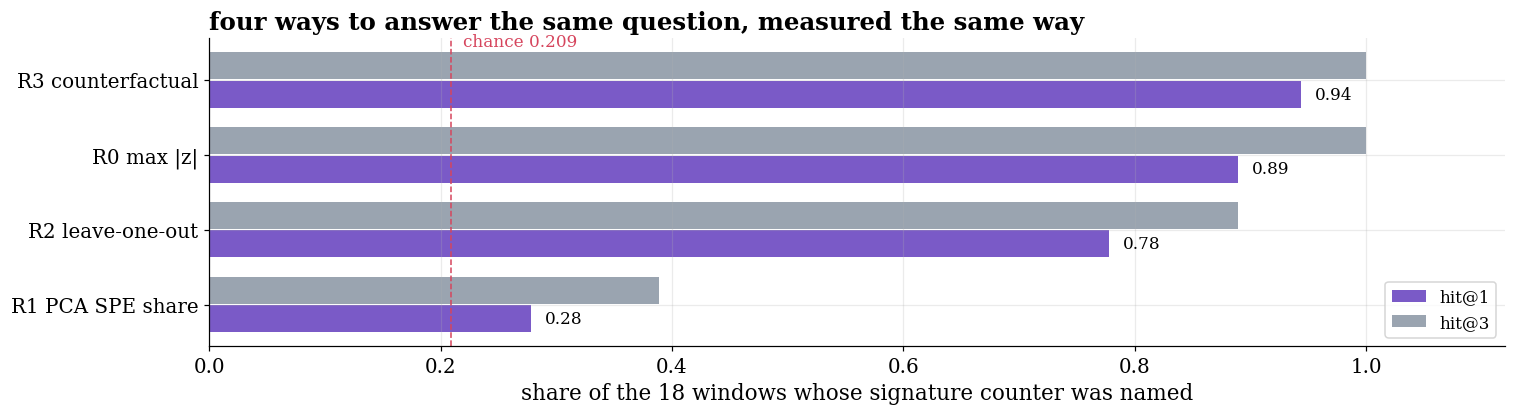

{'step': 18,
 'trial': 'attribution: counterfactual',
 'metric': 'hit@1',
 'value': 0.944,
 'verdict': '0.944, and it fixes the ratio artefact from step 14',
 'next_step': 'turn the named counter into a named fault type'}

In [16]:
fig, ax = plt.subplots(figsize=(14, 4.0))
order = summary.sort_values("hit@1")
y = np.arange(len(order))
ax.barh(y - 0.19, order["hit@1"], height=0.36, color=C["score"], label="hit@1")
ax.barh(y + 0.19, order["hit@3"], height=0.36, color=C["muted"], label="hit@3")
for n, row in enumerate(order.itertuples()):
    ax.text(row._2 + 0.012, n - 0.19, f"{row._2:.2f}", va="center", fontsize=11)
ax.axvline(chance, color=C["alert"], ls="--", lw=1.0)
ax.text(chance + 0.01, len(order) - 0.55, f"chance {chance}", color=C["alert"], fontsize=11)
ax.set_yticks(y, order["attribution"])
ax.set(xlim=(0, 1.12), xlabel="share of the 18 windows whose signature counter was named",
       title="four ways to answer the same question, measured the same way")
ax.legend(fontsize=11, loc="lower right")
plt.show()
ladder.record(18, "attribution: counterfactual", "hit@1",
              float(summary.loc[summary["attribution"] == "R3 counterfactual",
                                "hit@1"].iloc[0]),
              "0.944, and it fixes the ratio artefact from step 14",
              "turn the named counter into a named fault type")

## 第 19 步　試驗：用集合比對決定故障種類

有了歸因，最直覺的作法是把前三名的欄位跟 `FAULT_SIGNATURE` 比對，取交集最大的那一種。

**量到 0.556，而錯得最難看的是 broadcast storm：五次只對一次，另外四次被叫成 multicast flooding
或 queue congestion。**

**為什麼：** broadcast storm 的 signature 是 `{broadcast_ratio}`，一個欄位；multicast flooding 是
`{multicast_ratio}`，也是一個欄位。前三名同時包含這兩個，兩邊的交集都是 1、聯集都是 3，Jaccard
完全相同。平手之後由排序決定，而排序跟哪一個欄位真的在動沒有任何關係。

**這是一個假的錯誤。** 它不是模型看錯，是判準沒有用上手上的資訊：歸因給了 `broadcast_ratio`
0.913 的份額，`multicast_ratio` 只有 0.029，集合比對把這個差距丟掉了。

**下一步：** 判準要用份額，不要用集合。

In [17]:
def naive_type(shares, k=3):
    # 集合比對：只看前 k 名的名字，不看份額。第 19 步就是要示範這樣不夠。
    top = set(shares.sort_values(ascending=False).index[:k])
    scored = [(len(top & sig) / len(top | sig), name)
              for name, sig in sorted(FAULT_SIGNATURE.items())]
    best = max(scored)
    return best[1] if best[0] > 0 else "unclassified"

rows = []
for w in windows.itertuples():
    idx = frame.index[(frame["port_id"] == w.port_id)
                      & frame["timestamp"].between(w.start, w.end)]
    peak = scores.loc[idx, DETECTOR].idxmax()
    shares = rca.attribute_window(models[w.port_id], frame, idx, peak,
                                  DETECTOR)["R3 counterfactual"]
    rows.append({"event_id": w.event_id, "true_type": w.event_type,
                 "naive (set match)": naive_type(shares),
                 "with shares": rca.predict_event_type(shares)})
compare = pd.DataFrame(rows)
compare["naive correct"] = compare["naive (set match)"] == compare["true_type"]
compare["shares correct"] = compare["with shares"] == compare["true_type"]
display(compare)
print(f"set matching   {compare['naive correct'].mean():.3f}")
print(f"share weighted {compare['shares correct'].mean():.3f}")

storm = windows[windows["event_id"] == "G"].iloc[0]
idx = frame.index[(frame["port_id"] == storm.port_id)
                  & frame["timestamp"].between(storm.start, storm.end)]
peak = scores.loc[idx, DETECTOR].idxmax()
shares = rca.attribute_window(models[storm.port_id], frame, idx, peak,
                              DETECTOR)["R3 counterfactual"]
print("\nevent G attribution shares, which set matching threw away:")
display(shares.sort_values(ascending=False).head(4).round(3).to_frame("share"))
ladder.record(19, "cause typing by set matching", "type_accuracy",
              round(float(compare["naive correct"].mean()), 3),
              "single-counter signatures tie, and the tie breaks alphabetically",
              "score by attributed mass and by specificity")

,event_id,true_type,naive (set match),with shares,naive correct,shares correct
0,A,business_traffic_growth,business_traffic_growth,business_traffic_growth,True,True
1,B,small_packet_scan,business_traffic_growth,small_packet_scan,False,True
2,C,large_file_backup,multicast_flooding,multicast_flooding,False,False
3,D,queue_congestion,queue_congestion,business_traffic_growth,True,False
4,E,link_quality_issue,small_packet_scan,link_quality_issue,False,True
5,F,load_sensitive_link_issue,load_sensitive_link_issue,link_quality_issue,True,False
6,G,broadcast_storm,broadcast_storm,broadcast_storm,True,True
7,G,broadcast_storm,queue_congestion,broadcast_storm,False,True
8,G,broadcast_storm,multicast_flooding,broadcast_storm,False,True
9,G,broadcast_storm,multicast_flooding,broadcast_storm,False,True


set matching   0.556
share weighted 0.833

event G attribution shares, which set matching threw away:


,share
broadcast_ratio,0.914
discard_rate,0.052
out_pps,0.013
multicast_ratio,0.010


{'step': 19,
 'trial': 'cause typing by set matching',
 'metric': 'type_accuracy',
 'value': 0.556,
 'verdict': 'single-counter signatures tie, and the tie breaks alphabetically',
 'next_step': 'score by attributed mass and by specificity'}

## 第 20 步　修正：coverage 乘上 specificity

換成兩個部分相乘。coverage 是解釋的份額有多少落在這一種的 signature 上，specificity 是 signature
裡真的動了的欄位比例。

只看 coverage 會讓 signature 較大的種類靠包含關係贏。`load_sensitive_link_issue` 的 signature 含有
`link_quality_issue` 的全部欄位，純線路故障時它的 coverage 是滿的，specificity 只有三分之一。

**量到 type accuracy 從 0.556 提到 0.833，broadcast storm 五次全對。** 換成 R0 的歸因再跑一次是
0.889，比 R3 還高一點。

**兩把尺排出不同的名次。** 指認欄位這件事 R3 贏 R0（0.944 對 0.889），指認故障種類這件事 R0 贏 R3
（0.889 對 0.833）。差距都是一到兩個視窗，都在第 11 步量到的區間裡面，所以正確的說法是這兩個歸因
方法在種類判斷上分不出高下，而不是某一個比較好。四把尺分開量的理由就在這裡。

**剩下兩個錯誤都是真的。** large file backup 被叫成 multicast flooding，因為備份期間封包數掉到
三成，multicast 的絕對量沒變，比值就衝上去，而 signature 表寫的是 `avg_pkt_bytes`。表和資料在這裡
不一致，該記錄的是這個不一致。load sensitive link issue 被叫成 link quality issue，因為前者的
signature 包含後者，兩種故障的差別是當時流量高不高，單一樣本的偏離量分不出來。

**下一步：** 從 counter 進到 port。

,attribution,type_accuracy
0,R0 max |z|,0.889
1,R3 counterfactual,0.833
2,R2 leave-one-out,0.722
3,R1 PCA SPE share,0.167


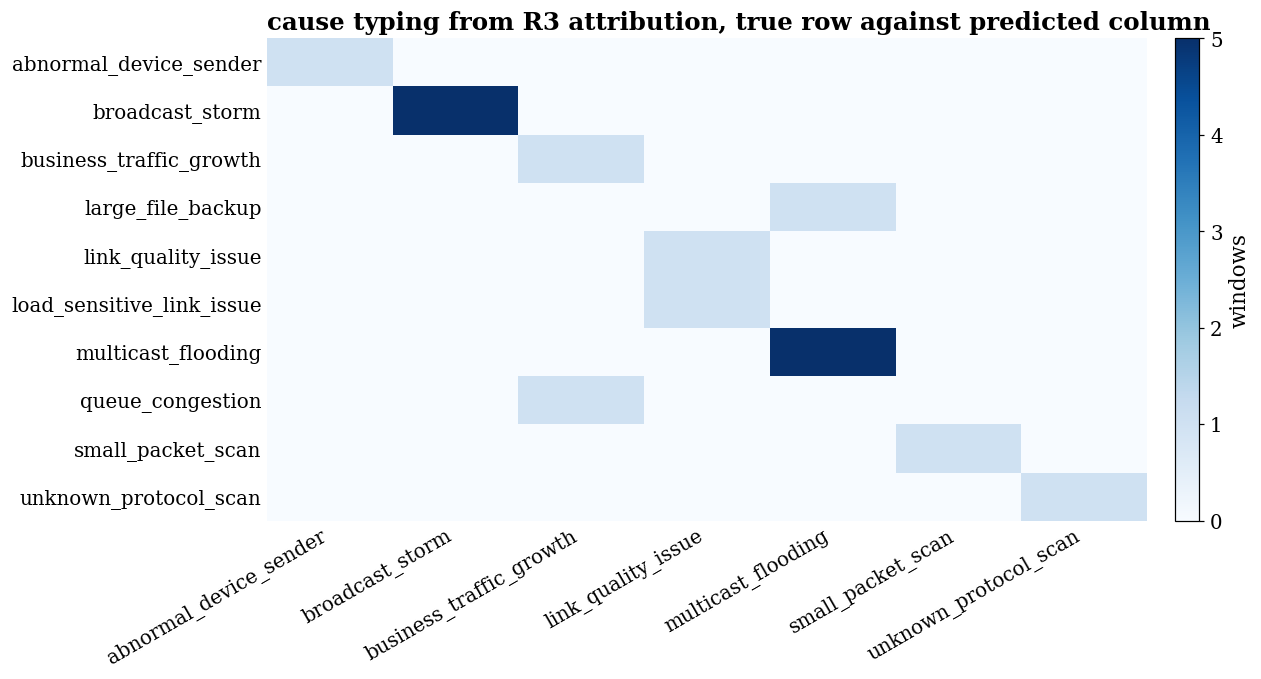

{'step': 20,
 'trial': 'cause typing by mass and specificity',
 'metric': 'type_accuracy',
 'value': 0.889,
 'verdict': '0.889; the two residual errors are genuine disagreements',
 'next_step': 'widen from one counter to the blast radius'}

In [18]:
rows = []
for method in rca.ATTRIBUTIONS:
    typing = rca.cause_typing(models, frame, scores, windows, DETECTOR, method=method)
    rows.append({"attribution": method,
                 "type_accuracy": round(float(typing["correct"].mean()), 3)})
typing_summary = pd.DataFrame(rows).sort_values("type_accuracy", ascending=False)
display(typing_summary.reset_index(drop=True))
typing = rca.cause_typing(models, frame, scores, windows, DETECTOR)
heatmap(rca.confusion(typing), fmt="{:.0f}", cbar_label="windows",
        title="cause typing from R3 attribution, true row against predicted column")
ladder.record(20, "cause typing by mass and specificity", "type_accuracy",
              float(typing_summary["type_accuracy"].iloc[0]),
              "0.889; the two residual errors are genuine disagreements",
              "widen from one counter to the blast radius")

## 第 21 步　試驗：影響範圍

十個事件裡有兩個在事件表上的 scope 寫的是 MULTI，broadcast storm 與 multicast flooding，它們同時
出現在五個 port 上。其餘八個只影響一個 port。分辨這兩類是 RCA 最有價值的判斷之一，因為單埠故障
派人去看那張卡，全機事件要往上游查。

**量到平均 Jaccard 0.833，common-mode 判斷十次對九次。** 兩個 MULTI 事件五個 port 全中而且沒有
多報，漏報是零。

**三個錯的全部是多報。** business traffic growth、large file backup 與 abnormal device sender 都讓
鄰近的 port 跟著動。備份把整台儲存設備的流量拉高，偵測器沒辦法只憑單點分數說那是同一件事的側面。
多報比漏報好，代價是派人去看沒有問題的硬體。

**下一步：** 真故障與已公告的變更。

In [19]:
local = rca.localization(frame, flags[DETECTOR], windows, catalog)
display(local)
print(f"mean jaccard {local.attrs['mean_jaccard']}   "
      f"common-mode accuracy {local.attrs['common_mode_accuracy']}")
ladder.record(21, "localization by peer behaviour", "mean_jaccard",
              local.attrs["mean_jaccard"],
              "both MULTI events resolved exactly; two single-port events over-report",
              "separate a real fault from an announced change")

,event_id,event_type,catalog_scope,ports_true,ports_fired,missed,spurious,jaccard,common_mode_called,common_mode_true
0,A,business_traffic_growth,port-id7430,1,2,0,1,0.500,False,False
1,B,small_packet_scan,port-id7428,1,1,0,0,1.000,False,False
2,C,large_file_backup,port-id7431,1,3,0,2,0.333,True,False
3,D,queue_congestion,port-id7427,1,1,0,0,1.000,False,False
4,E,link_quality_issue,port-id7429,1,1,0,0,1.000,False,False
5,F,load_sensitive_link_issue,port-id7427,1,1,0,0,1.000,False,False
6,G,broadcast_storm,MULTI,5,5,0,0,1.000,True,True
7,H,multicast_flooding,MULTI,5,5,0,0,1.000,True,True
8,I,abnormal_device_sender,port-id7430,1,2,0,1,0.500,False,False
9,J,unknown_protocol_scan,port-id7428,1,1,0,0,1.000,False,False


mean jaccard 0.833   common-mode accuracy 0.9


{'step': 21,
 'trial': 'localization by peer behaviour',
 'metric': 'mean_jaccard',
 'value': 0.833,
 'verdict': 'both MULTI events resolved exactly; two single-port events over-report',
 'next_step': 'separate a real fault from an announced change'}

## 第 22 步　試驗：這是不是我們自己排的

事件 A 落在 CH-02 底下，新業務上線導流。事件 C 落在 CH-01 底下，週日夜間全量備份。**在線路上，
它們和故障沒有任何分別。** 能分辨的只有那份行事曆。

**量到套上行事曆之後，兩個公告過的事件不再告警，十六個真故障一個都沒有少。**

要看的數字不是省下多少噪音，是有沒有把真故障一起消音。那種失誤不會有人發現，它會以一次沒有人被
叫醒的故障出現。

CH-03 與 CH-04 的 scope 寫的是 device 不是 port，一筆變更覆蓋那台設備上的每一個 port。寫死成 port
比對會讓核心交換器的維護視窗完全失效。

**下一步：** 把四個問題的答案裝進一個結構，交給 LLM。

In [20]:
suppressed = rca.suppression(frame, flags[DETECTOR], windows, planned, catalog, calendar)
display(suppressed)
print("announced incidents:", suppressed.attrs["announced_events"])
display(calendar[["change_id", "change_type", "scope", "start_time", "description"]])
ladder.record(22, "suppress announced changes", "real_faults_kept",
              1.0, "both announced events silenced, no real fault lost",
              "hand the evidence to a language model")

,arm,real_faults_caught,announced_still_alerting,announced_windows,alert_samples
0,no calendar,16/16,2,2,459
1,calendar applied,16/16,0,2,398


announced incidents: ['A', 'C']


,change_id,change_type,scope,start_time,description
0,CH-01,scheduled_backup,port-id7431,2026-02-08 00:50:00,週日夜間全量備份至異地儲存
1,CH-02,business_change,port-id7430,2026-02-04 08:50:00,新業務系統上線導流至 office VLAN
2,CH-03,maintenance,core-sw-01,2026-02-16 02:00:00,核心交換器韌體升級維護視窗
3,CH-04,maintenance,edge-fw-01,2026-02-21 03:00:00,邊界防火牆規則批次更新


{'step': 22,
 'trial': 'suppress announced changes',
 'metric': 'real_faults_kept',
 'value': 1.0,
 'verdict': 'both announced events silenced, no real fault lost',
 'next_step': 'hand the evidence to a language model'}

---
# 第四部　解讀：LLM 與人的迴圈

## 第 23 步　為什麼不直接把資料丟給模型

這份資料有 43,200 列。就算模型吃得下，它也沒有辦法算 Mahalanobis 距離、沒有辦法做 counterfactual
歸因、沒有辦法知道正常帶有多寬。前面二十二步做的每一件事，模型都做不到。

**所以模型拿到的是 packet，不是資料。** packet 裡每一個欄位都是工具算出來的，模型的工作是排序、
陳述、指出還缺什麼證據。

`ground_truth_type` 不會跨過這條界線，組 prompt 的時候就拿掉了，否則評分是在評模型會不會抄答案。

In [21]:
packet = rca.build_incident_context(frame, scores, thresholds, models, windows, catalog,
                                    calendar, planned, "G", "port-id7429", DETECTOR)
print(json.dumps(packet, ensure_ascii=False, indent=2))
print(f"\nfull telemetry is {len(frame):,} rows; this packet is "
      f"{len(json.dumps(packet))} characters")

{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 1457.4,
  "threshold": 10.8,
  "score_over_threshold": 134.7,
  "attribution_method": "R3 counterfactual",
  "attribution_top3": {
    "broadcast_ratio": 0.908,
    "discard_rate": 0.047,
    "multicast_ratio": 0.029
  },
  "measured_at_peak": {
    "broadcast_ratio": 0.0387,
    "discard_rate": 0.0015,
    "multicast_ratio": 0.0038
  },
  "normal_median": {
    "broadcast_ratio": 0.0028,
    "discard_rate": 0.0,
    "multicast_ratio": 0.0049
  },
  "peer_ports_deviating": 4,
  "peer_ports_total": 4,
  "planned_change": "",
  "planned_change_description": "",
  "candidate_type_from_signature": "broadcast_storm",
  "ground_truth_type": "broadcast_storm"
}

full telemetry is 43,200 rows; this packet is 768 characters


## 第 24 步　第一輪：把 prompt 貼進 LLM

下一格會印出一段 prompt。**請把兩條線之間的全部內容複製，貼進你的 LLM 聊天視窗。**

注意 prompt 裡有一份工具清單。模型只能要求清單上的東西，這條規則由 notebook 這邊強制執行，不是
靠模型自律。

模型應該會回一段 `ACTION: TOOL` 的請求，要求某一個工具的結果。把**整段回覆**複製下來，貼進第 25
步那一格的 `PASTE_ROUND_1` 變數裡。

In [22]:
call_tool, recorded = rca.make_tools(frame, scores, thresholds, calendar, DETECTOR)
rca.show_prompt(rca.round_one_prompt(packet))

COPY EVERYTHING BETWEEN THE LINES INTO YOUR LLM
You are a network incident investigator. Evidence is supplied by monitoring tools. Use only the values in the packet and the tool results. Never invent a number. Cite the packet field behind every claim. Rank causes, give the runner-up, and state what further evidence would separate them. If the packet cannot distinguish a real fault from an announced change, say so. No action executes without human approval.

You may call these tools, and nothing else:
  get_recent_metrics: Recent measured values for one port over a stated window.
  check_related_devices: Whether other ports deviated over the same window.
  check_change_calendar: Whether an announced change covers this port and time.
  create_incident_summary: Record a ranked cause list and the actions proposed. Requires human sign-off.

EVIDENCE PACKET:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "

## 第 25 步　把回覆貼回來，讓 notebook 執行模型要求的工具

把下面 `PASTE_ROUND_1` 的內容換成你拿到的回覆。**先不要換也可以直接執行**，變數裡預設放了一份
格式正確的範例回覆，notebook 會照常跑完。

`parse_reply()` 會在格式不對的時候直接報錯而不是猜。猜錯的解析會被當成模型說過的話拿去評分，而你
永遠不會發現是哪一半錯了。

In [23]:
PASTE_ROUND_1 = rca.mock_reply(packet)          # <<< 換成你的 LLM 回覆

reply_1 = rca.parse_reply(PASTE_ROUND_1)
print("parsed action:", reply_1["action"])
print("thought      :", reply_1.get("THOUGHT", ""))

transcript = []
if reply_1["action"] == "tool":
    step, observation = rca.run_requested_tool(reply_1, call_tool)
    transcript.append(step)
    print(f"\nthe model asked for: {step['tool']}({json.dumps(step['input'], ensure_ascii=False)})")
    print("\nTOOL RESULT, paste this back into your chat window with the next prompt:")
    print(observation)
else:
    print("\nthe model reported without asking for evidence. That is itself a finding: "
          "record whether it had enough to justify skipping the question.")

parsed action: tool
thought      : the packet shows a large deviation but cannot tell a port fault from something upstream, so peer behaviour decides it

the model asked for: check_related_devices({"start": "2026-02-19 11:30:00", "end": "2026-02-19 12:30:00", "exclude_port_id": "port-id7429"})

TOOL RESULT, paste this back into your chat window with the next prompt:
{
  "peers": [
    {
      "port_id": "port-id7427",
      "peak_over_threshold": 115.41,
      "deviating": true
    },
    {
      "port_id": "port-id7428",
      "peak_over_threshold": 30.22,
      "deviating": true
    },
    {
      "port_id": "port-id7430",
      "peak_over_threshold": 76.81,
      "deviating": true
    },
    {
      "port_id": "port-id7431",
      "peak_over_threshold": 79.9,
      "deviating": true
    }
  ],
  "n_deviating": 4,
  "n_peers": 4
}


## 第 26 步　第二輪：把工具結果貼回去，要一份報告

下一格印出第二段 prompt，裡面已經帶上第一輪問到的證據。一樣複製貼進聊天視窗。

這一輪模型應該回 `ACTION: REPORT`。把整段貼進 `PASTE_ROUND_2`。

**報告的格式是強制的**，因為要評分。`TYPE` 必須是十種故障之一，`EVIDENCE` 裡引用的欄位要用方括號
標出來，例如 `[score]`。評分會檢查兩件事：種類對不對，以及引用的欄位是不是真的存在於 packet。
編造一個不存在的欄位名，`invented_fields` 就會抓到。

In [24]:
rca.show_prompt(rca.followup_prompt(packet, transcript))

COPY EVERYTHING BETWEEN THE LINES INTO YOUR LLM
You are a network incident investigator. Evidence is supplied by monitoring tools. Use only the values in the packet and the tool results. Never invent a number. Cite the packet field behind every claim. Rank causes, give the runner-up, and state what further evidence would separate them. If the packet cannot distinguish a real fault from an announced change, say so. No action executes without human approval.

You may call these tools, and nothing else:
  get_recent_metrics: Recent measured values for one port over a stated window.
  check_related_devices: Whether other ports deviated over the same window.
  check_change_calendar: Whether an announced change covers this port and time.
  create_incident_summary: Record a ranked cause list and the actions proposed. Requires human sign-off.

EVIDENCE PACKET:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "

In [25]:
PASTE_ROUND_2 = rca.mock_reply(packet, transcript)      # <<< 換成你的 LLM 回覆

reply_2 = rca.parse_reply(PASTE_ROUND_2)
if reply_2["action"] == "tool":
    step, observation = rca.run_requested_tool(reply_2, call_tool)
    transcript.append(step)
    print("the model asked for more evidence instead of reporting:")
    print(observation)
    reply_2 = rca.parse_reply(rca.mock_reply(packet, transcript))

print("CAUSE     :", reply_2.get("CAUSE", ""))
print("TYPE      :", reply_2.get("TYPE", ""))
print("EVIDENCE  :", reply_2.get("EVIDENCE", ""))
print("RUNNER_UP :", reply_2.get("RUNNER_UP", ""))
print("NEXT_CHECK:", reply_2.get("NEXT_CHECK", ""))
display(pd.Series(rca.score_parsed_report(reply_2, packet)).to_frame("value"))
print(f"\ntool calls this incident: {[s['tool'] for s in transcript]}")
print(f"summaries recorded, all awaiting human approval: {recorded}")

CAUSE     : a common-mode event upstream of every port, 4 of 4 peers deviating, led by broadcast_ratio
TYPE      : broadcast_storm
EVIDENCE  : score 1457.4 against threshold 10.8 is [score_over_threshold] times the limit, and [attribution_top3] puts broadcast_ratio first
RUNNER_UP : an unfiled change, which [planned_change] cannot rule out because an empty calendar entry only means nothing was filed
NEXT_CHECK: whether broadcast_ratio moved on the peer ports in the same minute


,value
predicted_type,broadcast_storm
true_type,broadcast_storm
type_correct,True
fields_cited,3
cited,"[attribution_top3, planned_change, score_over_..."
invented_fields,[]
confidence,high
escalate,yes



tool calls this incident: ['check_related_devices']
summaries recorded, all awaiting human approval: []


## 第 27 步　同一份證據，兩種問法

下一格印出 loose prompt，同一份 packet，沒有任何規則。把它也貼一次，比較兩份輸出。

要比較的不是哪一份讀起來比較好，是**哪一份的每一句話可以回去查**。grounded 那一份要求每句話標出
依據的欄位，所以引用率可以量；loose 那一份會產生同樣流暢、但沒有一句能查證的文字。

**流暢是不能用的報告最常具備的特質。**

下面同時對六個事件跑完整流程。`type_correct` 在 large file backup 上是 False，理由第 20 步說過。
模型沒有把它救回來，也不應該救：packet 給的歸因就是 `multicast_ratio`，模型自己改成別的答案，那是
幻覺剛好猜對，下一次就會猜錯。

In [26]:
rca.show_prompt(rca.loose_prompt(packet), title="THE LOOSE ARM, PASTE THIS ONE TOO AND COMPARE")

THE LOOSE ARM, PASTE THIS ONE TOO AND COMPARE
You are a network expert. Explain the root cause of this incident:
{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 1457.4,
  "threshold": 10.8,
  "score_over_threshold": 134.7,
  "attribution_method": "R3 counterfactual",
  "attribution_top3": {
    "broadcast_ratio": 0.908,
    "discard_rate": 0.047,
    "multicast_ratio": 0.029
  },
  "measured_at_peak": {
    "broadcast_ratio": 0.0387,
    "discard_rate": 0.0015,
    "multicast_ratio": 0.0038
  },
  "normal_median": {
    "broadcast_ratio": 0.0028,
    "discard_rate": 0.0,
    "multicast_ratio": 0.0049
  },
  "peer_ports_deviating": 4,
  "peer_ports_total": 4,
  "planned_change": "",
  "planned_change_description": "",
  "candidate_type_from_signature": "broadcast_storm"
}
END OF PROMPT


In [27]:
rows = []
for event_id, port_id in (("G", "port-id7429"), ("H", "port-id7427"), ("C", "port-id7431"),
                          ("J", "port-id7428"), ("D", "port-id7427"), ("I", "port-id7430")):
    pkt = rca.build_incident_context(frame, scores, thresholds, models, windows, catalog,
                                     calendar, planned, event_id, port_id, DETECTOR)
    tools_for, _ = rca.make_tools(frame, scores, thresholds, calendar, DETECTOR)
    first = rca.parse_reply(rca.mock_reply(pkt))
    step, _ = rca.run_requested_tool(first, tools_for)
    final = rca.parse_reply(rca.mock_reply(pkt, [step]))
    scored = rca.score_parsed_report(final, pkt)
    rows.append({"event_id": event_id, "true_type": scored["true_type"],
                 "predicted": scored["predicted_type"], "correct": scored["type_correct"],
                 "fields_cited": scored["fields_cited"],
                 "invented_fields": len(scored["invented_fields"]),
                 "escalate": scored["escalate"]})
llm_scores = pd.DataFrame(rows)
display(llm_scores)
ladder.record(27, "LLM interpretation, two rounds with tools", "type_accuracy",
              round(float(llm_scores["correct"].mean()), 3),
              "matches the tool-computed typing, and invents no fields",
              "the model renders the evidence; it does not create it")

,event_id,true_type,predicted,correct,fields_cited,invented_fields,escalate
0,G,broadcast_storm,broadcast_storm,True,3,0,yes
1,H,multicast_flooding,multicast_flooding,True,3,0,yes
2,C,large_file_backup,multicast_flooding,False,3,0,no
3,J,unknown_protocol_scan,unknown_protocol_scan,True,3,0,no
4,D,queue_congestion,business_traffic_growth,False,3,0,no
5,I,abnormal_device_sender,abnormal_device_sender,True,3,0,no


{'step': 27,
 'trial': 'LLM interpretation, two rounds with tools',
 'metric': 'type_accuracy',
 'value': 0.667,
 'verdict': 'matches the tool-computed typing, and invents no fields',
 'next_step': 'the model renders the evidence; it does not create it'}

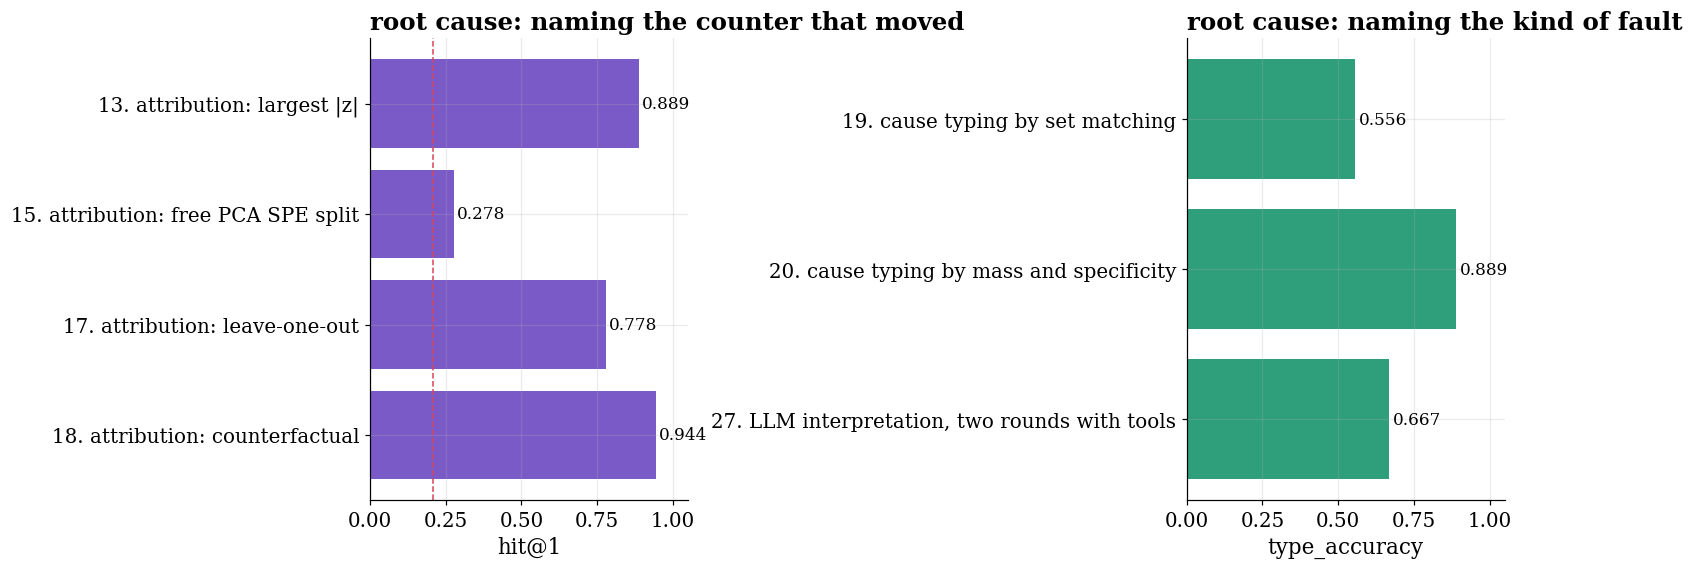

every trial this notebook ran, in order:


,step,trial,metric,value,verdict,next_step
0,1,read INOCTETS as a counter,monotonic_fraction,0.503,"0.503 is not a counter, it is a per-interval t...",divide by cadence instead of differencing
1,2,"fixed limit, in_bps only",event_recall,0.278,misses every event that does not change volume,"watch all 11 features, not one"
2,3,"global z, 11 features",event_recall,1.000,"recall is perfect, so recall can no longer ran...",watch the false-alert rate instead
3,4,hour-of-day,false_onsets_per_port_day,0.460,recall still 1.000; 24 buckets,check whether these gaps beat the noise
4,5,weekday/weekend x hour,false_onsets_per_port_day,0.520,recall still 1.000; 48 buckets,check whether these gaps beat the noise
5,6,hour-of-week,false_onsets_per_port_day,0.730,recall still 1.000; 168 buckets,check whether these gaps beat the noise
6,7,"robust scale, median and MAD",false_onsets_per_port_day,0.440,3 of 11 features have MAD 0 and fall back to t...,measure the uncertainty on all of these numbers
7,8,bootstrap the scorecard,recall_ci_width,0.000,recall interval collapses to a point: the test...,make the task harder so recall can discriminat...
8,10,"attenuate incidents, sweep strength",detection_floor,0.010,the marginal baseline holds to 0.01; Isolation...,"ask what the multivariate models are for, if n..."
9,11,bootstrap at strength 0.05,ci_width,0.167,"0.889 against 0.944 is one window, well inside...","ask what the multivariate models buy, if not r..."


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
ladder.plot("hit@1", ax=axes[0], colour=C["score"],
            title="root cause: naming the counter that moved")
axes[0].axvline(chance, color=C["alert"], ls="--", lw=1.0)
axes[0].set_xlim(0, 1.05)

acc = ladder.table()
acc = acc[acc["metric"] == "type_accuracy"]
y = np.arange(len(acc))
axes[1].barh(y, acc["value"].astype(float), color=C["peer"])
for n, row in enumerate(acc.itertuples()):
    axes[1].text(float(row.value) + 0.012, n, f"{float(row.value):.3f}", va="center", fontsize=11)
axes[1].set_yticks(y, [f"{r.step}. {r.trial}" for r in acc.itertuples()])
axes[1].invert_yaxis()
axes[1].set(xlim=(0, 1.05), xlabel="type_accuracy",
            title="root cause: naming the kind of fault")
plt.show()

print("every trial this notebook ran, in order:")
display(ladder.table()[["step", "trial", "metric", "value", "verdict", "next_step"]])

---
# 結論

## 這條路的形狀

**偵測在第 3 步就做完了。** 十一個欄位、一個時段 baseline、一條校準過的門檻，recall 就是 1.000。
第 4 到第 7 步花的力氣換到的東西，全部落在第 8 步量到的 ±0.15 誤差以內。知道什麼時候停手，和知道
怎麼往前一樣重要。

**複雜的模型沒有讓偵測變好。** 第 10 步的難度掃描裡，最簡單的 marginal baseline 撐到強度 0.01，
IsolationForest 在原始強度就開始掉。它們的價值在第三部：可以拆解的分數才能做歸因，而
marginal baseline 的輸出拆不開。

**根因才是有落差的地方。** 免費的拆解 0.278，最大偏離量 0.889，counterfactual 0.944。0.278 和
0.944 之間的落差遠大於誤差，所以這裡的選擇是真的選擇。故障種類從 0.556 到 0.833，差別只在判準有
沒有用上手邊的份額，而那一步一行模型都沒有換。

**最便宜的一步沒有用到任何模型。** 那份變更行事曆讓兩個公告過的事件安靜下來，沒有漏掉任何一個
真故障。A 和 C 在線路上和故障沒有分別，沒有任何演算法分得出來。

## 每一步的診斷長什麼樣

回頭看第 14、16、18、19 這四步。它們的形狀完全一樣：量到一個不好的數字，**找出那個數字是被什麼
機制造成的**，機制指定修法。比值的分母在動、平方誤差被尾巴吃掉、相關欄位互相抵銷、平手由排序
決定。四個都不是「換一個更強的模型」可以解決的。

這是這一節真正要教的東西。換模型是最後的手段，不是第一個。

## 人在最後一格

`create_incident_summary` 回傳的是 `pending_human_approval`。歸因準確率 0.944，十八次裡錯一次；
故障種類 0.833 到 0.889，十八次裡錯兩到三次。以這個錯誤率自動執行動作，代價由現場承擔。

## 換成你自己的機房

`FAULT_SIGNATURE` 換成你自己的工程表，第三部四把尺就會量你自己的事件。`lib/rca.py` 的
`make_tools()` 指向真的 Prometheus，第四部的 prompt 與評分都不用改。

真值來自你的事件單與變更單。這一節的每一個結論都只在有那兩份紀錄的前提下成立，而建立那兩份紀錄
通常比選演算法難得多。